# Project: Edge AI

# Age, Gender, and Emotion Recognition

# Model Training and Evaluation

This notebook implements the complete training and evaluation pipeline for a multi-head deep learning model that performs age group classification, gender classification, and facial emotion recognition from images. A MobileNetV2 backbone pre-trained on ImageNet is used as a shared feature extractor, with separate task-specific heads for age, gender, and emotion prediction.

The model is trained in two stages: first, the backbone is fine-tuned on the FairFace dataset for age and gender classification; second, the emotion classification head is added and trained on the FER2013 dataset while freezing the previously learned parameters. Training and validation performance are evaluated using cross-entropy loss and classification accuracy, and early stopping is applied to prevent overfitting. The final trained model is saved as a reusable checkpoint for subsequent inference and edge deployment.


## Step 1: Imports for the Colab notebook

In [1]:
# --- Core Python utilities ---
import os          # Work with file paths, directories, environment variables
import random      # For Python-level randomness (e.g., shuffling)

# --- Numerical computing ---
import numpy as np  # Fast arrays, math operations, useful with PyTorch

# --- PyTorch core ---
import torch
from torch import nn                      # Neural network building blocks (layers, loss functions etc.)
from torch.utils.data import Dataset, DataLoader  # Custom datasets + mini-batch loading

# --- Torchvision: models and transforms for images ---
from torchvision import models, transforms

# --- HuggingFace datasets: to load FairFace & RAF-DB ---
from datasets import load_dataset
from datasets import DownloadConfig

# --- Progress bar for training loops ---
from tqdm.auto import tqdm

# --- Plotting (optional but very helpful to debug / inspect images) ---
import matplotlib.pyplot as plt


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Device + random seeds + basic config

In [3]:
# --- Reproducibility: set random seeds ---
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Ensures deterministic behaviour in some CUDA ops (can slow things a bit)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Device selection: use GPU if available, otherwise CPU ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Basic configuration ---
BATCH_SIZE = 64
NUM_WORKERS = 2   # start small; can increase later
IMAGE_SIZE = 224  # MobileNetV2 default input size


Using device: cuda


## Step 3: Load FairFace via HuggingFace and inspect

In [ ]:
#!rm -rf ~/.cache/huggingface/datasets/HuggingFaceM4*
# only clear cache when donload get's stuck


In [4]:
# --- Load the FairFace dataset from HuggingFace ---

from datasets import load_dataset, DownloadConfig

download_config = DownloadConfig(
    max_retries=5,
    resume_download=True,
)

fairface = load_dataset(
    "HuggingFaceM4/FairFace",
    "0.25",             # same smaller config as before
    download_config=download_config,
)

print(fairface)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

0.25/train-00000-of-00002-d405faba4f4b9b(…):   0%|          | 0.00/250M [00:00<?, ?B/s]

0.25/train-00001-of-00002-dd3cb681647274(…):   0%|          | 0.00/250M [00:00<?, ?B/s]

0.25/validation-00000-of-00001-951dbd63c(…):   0%|          | 0.00/63.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/86744 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10954 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'age', 'gender', 'race', 'service_test'],
        num_rows: 86744
    })
    validation: Dataset({
        features: ['image', 'age', 'gender', 'race', 'service_test'],
        num_rows: 10954
    })
})


In [5]:
# Let's inspect the feature description of the train split
train_features = fairface["train"].features
print(train_features)

# If 'age' and 'gender' are ClassLabel features, we can inspect their class names:
age_feature = train_features["age"]
gender_feature = train_features["gender"]

print("Age classes:", age_feature.names)
print("Gender classes:", gender_feature.names)

# Look at one concrete example to see fields and their types
example = fairface["train"][0]
print("\nExample entry keys:", example.keys())
print("Example ages:", example["age"])
print("Example gender:", example["gender"])
print("Example image type:", type(example["image"]))


{'image': Image(mode=None, decode=True), 'age': ClassLabel(names=['0-2', '3-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', 'more than 70']), 'gender': ClassLabel(names=['Male', 'Female']), 'race': ClassLabel(names=['East Asian', 'Indian', 'Black', 'White', 'Middle Eastern', 'Latino_Hispanic', 'Southeast Asian']), 'service_test': Value('bool')}
Age classes: ['0-2', '3-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', 'more than 70']
Gender classes: ['Male', 'Female']

Example entry keys: dict_keys(['image', 'age', 'gender', 'race', 'service_test'])
Example ages: 6
Example gender: 0
Example image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>


## Step 4: Define transforms (train & validation)

In [6]:
# --- Image transforms for MobileNetV2 ---

# Normalization values for ImageNet-pretrained models
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),  # simple augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


## Step 5.1 – Custom PyTorch Dataset (FairFace → tensors)

In [7]:
class FairFaceAgeGenderDataset(Dataset):
    """
    PyTorch Dataset wrapper for the HuggingFace FairFace split.
    Returns:
      image_tensor: FloatTensor (3, H, W)
      labels: dict with
          'age'    -> 0 = child, 1 = adult, 2 = elderly
          'gender' -> 0 = Male, 1 = Female
    """

    def __init__(self, hf_dataset, transform=None):
        """
        hf_dataset: one split of the HF DatasetDict, e.g. fairface['train']
        transform: torchvision transform pipeline to apply to the image
        """
        self.ds = hf_dataset
        self.transform = transform

    def __len__(self):
        # Total number of samples in this split
        return len(self.ds)

    def _map_age_bin_to_child_adult_elderly(self, age_bin_idx: int) -> int:
        """
        Map FairFace age bins (0-8) to three age classes:

            0 -> child   (bins 0-1: 0-2, 3-9)
            1 -> adult   (bins 2-6: 10-59)
            2 -> elderly (bins 7-8: 60-69, 70+)
        """
        if age_bin_idx <= 1:
            return 0   # child
        elif age_bin_idx <= 6:
            return 1   # adult
        else:
            return 2   # elderly

    def __getitem__(self, idx):
        """
        Return a single sample:
          image_tensor, labels_dict
        """
        item = self.ds[idx]

        # PIL image
        image = item["image"]

        # Original labels are integer indices
        age_bin_idx = int(item["age"])      # 0..8
        gender_idx  = int(item["gender"])   # 0..1 (Male/Female)

        # Map 9 age bins -> our 3 age classes
        age_label = self._map_age_bin_to_child_adult_elderly(age_bin_idx)

        # Keep gender as is: 0 = Male, 1 = Female
        gender_label = gender_idx

        # Apply transforms: resize, flip (train), tensor, normalize
        if self.transform is not None:
            image = self.transform(image)

        # Convert labels to tensors of type long (needed for CrossEntropyLoss)
        age_label_tensor = torch.tensor(age_label, dtype=torch.long)
        gender_label_tensor = torch.tensor(gender_label, dtype=torch.long)

        labels = {
            "age": age_label_tensor,
            "gender": gender_label_tensor,
        }

        return image, labels


## Step 5.2 – Build train/val Datasets and DataLoaders

In [8]:
# --- Create PyTorch datasets from HuggingFace splits ---

train_dataset = FairFaceAgeGenderDataset(
    hf_dataset=fairface["train"],
    transform=train_transform,
)

val_dataset = FairFaceAgeGenderDataset(
    hf_dataset=fairface["validation"],
    transform=val_transform,
)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

# --- DataLoaders ---

pin_memory = True if device.type == "cuda" else False

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,               # shuffle for training
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,              # no shuffle for validation
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

# --- Inspect one batch to verify shapes and labels ---

batch = next(iter(train_loader))
images, labels = batch

print("Batch image tensor shape:", images.shape)
print("Batch age labels shape:", labels['age'].shape)
print("Batch gender labels shape:", labels['gender'].shape)

print("Unique age labels in this batch:", torch.unique(labels["age"]))
print("Unique gender labels in this batch:", torch.unique(labels["gender"]))


Train dataset size: 86744
Validation dataset size: 10954
Batch image tensor shape: torch.Size([64, 3, 224, 224])
Batch age labels shape: torch.Size([64])
Batch gender labels shape: torch.Size([64])
Unique age labels in this batch: tensor([0, 1, 2])
Unique gender labels in this batch: tensor([0, 1])


## (Optional) Visual sanity check with new age mapping

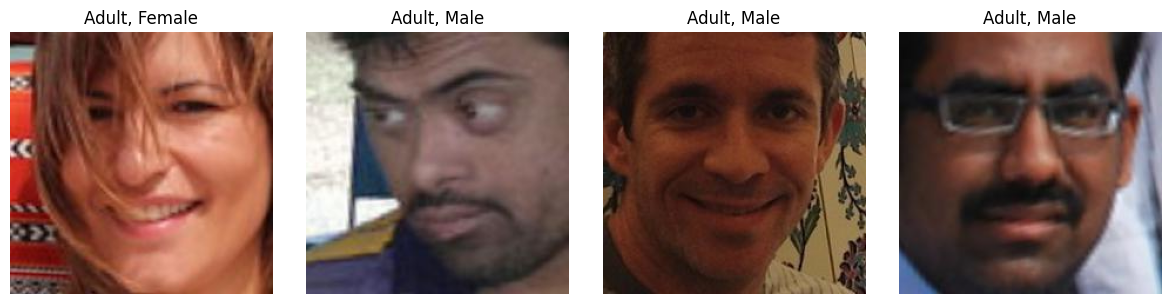

In [9]:
def denormalize(img_tensor):
    """
    Undo ImageNet normalization so we can display the image correctly.
    img_tensor: shape (3, H, W)
    """
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return img_tensor * std + mean

# Get one batch
images, labels = next(iter(train_loader))

num_show = 4
fig, axes = plt.subplots(1, num_show, figsize=(12, 3))

for i in range(num_show):
    img = images[i].cpu()
    img = denormalize(img).clamp(0, 1)  # keep values in [0,1]

    age = labels["age"][i].item()
    gender = labels["gender"][i].item()

    if age == 0:
        age_str = "Child"
    elif age == 1:
        age_str = "Adult"
    else:
        age_str = "Elderly"

    gender_str = "Male" if gender == 0 else "Female"

    axes[i].imshow(np.transpose(img.numpy(), (1, 2, 0)))
    axes[i].set_title(f"{age_str}, {gender_str}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## Step 6 – Simple Multi-Head MobileNetV2

## 6.1 Define the model class

In [10]:
# --- Simple multi-head MobileNetV2 model ---

class AgeGenderNet(nn.Module):
    """
    MobileNetV2 backbone with:
      - age head:    3 classes (child, adult, elderly)
      - gender head: 2 classes (male, female)
    """

    def __init__(self):
        super().__init__()

        # 1) Load pretrained MobileNetV2
        self.backbone = models.mobilenet_v2(pretrained=True)

        # 2) Get how many features go into the original classifier (usually 1280)
        in_features = self.backbone.classifier[1].in_features

        # 3) Remove the original classifier (1000 ImageNet classes)
        #    and make it an "identity": output the feature vector instead
        self.backbone.classifier = nn.Identity()

        # 4) Our two small heads on top of the shared features
        self.age_head = nn.Linear(in_features, 3)   # child / adult / elderly
        self.gender_head = nn.Linear(in_features, 2)  # male / female

    def forward(self, x):
        # Extract shared features from the backbone
        feats = self.backbone(x)  # shape: (batch_size, in_features)

        # Apply heads
        age_logits = self.age_head(feats)        # (batch_size, 3)
        gender_logits = self.gender_head(feats)  # (batch_size, 2)

        # Return both outputs
        return age_logits, gender_logits



## 6.2 Create the model and do a quick test

In [11]:
# --- Create model and move to device ---

model = AgeGenderNet().to(device)

# --- Quick sanity check: forward pass on one batch ---

images, labels = next(iter(train_loader))
images = images.to(device)

age_logits, gender_logits = model(images)

print("Images shape:        ", images.shape)
print("Age logits shape:    ", age_logits.shape)     # expected: (B, 3)
print("Gender logits shape: ", gender_logits.shape)  # expected: (B, 2)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 23.2MB/s]


Images shape:         torch.Size([64, 3, 224, 224])
Age logits shape:     torch.Size([64, 3])
Gender logits shape:  torch.Size([64, 2])


In [12]:
print(model)

AgeGenderNet(
  (backbone): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kernel_size=

## Step 7 – Define losses + optimizer (simple)

In [13]:
# --- Loss functions for each head ---

age_criterion = nn.CrossEntropyLoss()     # for 3 age classes: child/adult/elderly
gender_criterion = nn.CrossEntropyLoss()  # for 2 gender classes: male/female

# --- Optimizer ---

LEARNING_RATE = 1e-4

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Using learning rate:", LEARNING_RATE)


Using learning rate: 0.0001


## Step 8 – Simple training + validation loop + early stopping

In [14]:
def accuracy_from_logits(logits, targets):
    """
    logits: tensor of shape (batch_size, num_classes)
    targets: tensor of shape (batch_size,) with class indices
    returns: accuracy as a float (0.0 - 1.0)
    """
    preds = logits.argmax(dim=1)           # index of max logit = predicted class
    correct = (preds == targets).sum().item()
    total = targets.size(0)
    return correct / total


In [15]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        """
        patience: how many epochs with no improvement to wait before stopping
        min_delta: minimum change in val_loss to count as improvement
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss):
        # First epoch
        if self.best_loss is None:
            self.best_loss = val_loss
            return False

        # If loss improved enough
        if self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return False
        else:
            # No sufficient improvement
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            return self.should_stop


## Appendix: One-cell timing utility for Google Colab

In [16]:
import time
from datetime import timedelta

class Timer:
    def __init__(self):
        self.start_time = None
        self.events = []

    def start(self):
        self.start_time = time.time()

    def stop(self, label=""):
        if self.start_time is None:
            raise ValueError("Timer not started!")
        elapsed = time.time() - self.start_time
        self.events.append((label, elapsed))
        print(f"{label}: {timedelta(seconds=elapsed)}")
        self.start_time = None  # reset so timer must be restarted

    def summary(self):
        print("\n--- Runtime Summary ---")
        for label, elapsed in self.events:
            print(f"{label}: {timedelta(seconds=elapsed)}")

## 8.2 Training loop

In [17]:
# Create a Timer instance to measure the total runtime of the Age+Gender training
timer = Timer()

# Start measuring the runtime for the complete Age+Gender training process
timer.start()  # ⏱ begins wall-clock timing

# Maximum number of epochs (training iterations over the full dataset).
# Training may stop earlier due to early stopping.
NUM_EPOCHS = 20

# Initialize early stopping mechanism.
# patience=3  → stop training if validation loss does not improve for 3 consecutive epochs
# min_delta=0 → any improvement in validation loss counts as progress
early_stopper = EarlyStopping(patience=3, min_delta=0.0)

# =========================
# MAIN TRAINING LOOP
# =========================
for epoch in range(1, NUM_EPOCHS + 1):
    # Print current epoch information
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print("-" * 30)

    # -------------------------------------------------
    # TRAINING PHASE
    # -------------------------------------------------
    # Switch model to training mode.
    # This enables layers such as Dropout and BatchNorm to behave correctly.
    model.train()

    # Initialize accumulators for tracking training statistics
    train_loss_sum = 0.0              # Sum of total loss values
    train_age_acc_sum = 0.0           # Sum of age classification accuracies
    train_gender_acc_sum = 0.0        # Sum of gender classification accuracies
    train_batches = 0                 # Number of processed batches

    # Iterate over all training batches
    for images, labels in train_loader:
        # Move input images and labels to the selected device (CPU or GPU)
        images = images.to(device)
        age_labels = labels["age"].to(device)
        gender_labels = labels["gender"].to(device)

        # Reset gradients from the previous optimization step
        optimizer.zero_grad()

        # Forward pass through the model
        # The model outputs two prediction heads:
        #  - age_logits: raw age class scores
        #  - gender_logits: raw gender class scores
        age_logits, gender_logits = model(images)

        # Compute task-specific losses
        # Age classification loss
        age_loss = age_criterion(age_logits, age_labels)
        # Gender classification loss
        gender_loss = gender_criterion(gender_logits, gender_labels)

        # Combine both losses into a single optimization objective
        loss = age_loss + gender_loss

        # Backpropagation:
        # Compute gradients of the loss with respect to model parameters
        loss.backward()

        # Update model parameters using the optimizer
        optimizer.step()

        # Accumulate loss and accuracy statistics for this batch
        train_loss_sum += loss.item()
        train_age_acc_sum += accuracy_from_logits(age_logits, age_labels)
        train_gender_acc_sum += accuracy_from_logits(gender_logits, gender_labels)
        train_batches += 1

    # Compute average training metrics over all batches
    avg_train_loss = train_loss_sum / train_batches
    avg_train_age_acc = train_age_acc_sum / train_batches
    avg_train_gender_acc = train_gender_acc_sum / train_batches

    # Print training results for the current epoch
    print(f"Train loss: {avg_train_loss:.4f}")
    print(f"Train age accuracy:    {avg_train_age_acc * 100:.2f}%")
    print(f"Train gender accuracy: {avg_train_gender_acc * 100:.2f}%")

    # -------------------------------------------------
    # VALIDATION PHASE
    # -------------------------------------------------
    # Switch model to evaluation mode.
    # This disables Dropout and uses running statistics for BatchNorm.
    model.eval()

    # Initialize accumulators for validation statistics
    val_loss_sum = 0.0
    val_age_acc_sum = 0.0
    val_gender_acc_sum = 0.0
    val_batches = 0

    # Disable gradient computation during validation
    # This reduces memory usage and speeds up computation
    with torch.no_grad():
        # Iterate over validation batches
        for images, labels in val_loader:
            # Move validation data to the correct device
            images = images.to(device)
            age_labels = labels["age"].to(device)
            gender_labels = labels["gender"].to(device)

            # Forward pass (no gradients are computed)
            age_logits, gender_logits = model(images)

            # Compute validation losses
            age_loss = age_criterion(age_logits, age_labels)
            gender_loss = gender_criterion(gender_logits, gender_labels)
            loss = age_loss + gender_loss

            # Accumulate validation statistics
            val_loss_sum += loss.item()
            val_age_acc_sum += accuracy_from_logits(age_logits, age_labels)
            val_gender_acc_sum += accuracy_from_logits(gender_logits, gender_labels)
            val_batches += 1

    # Compute average validation metrics
    avg_val_loss = val_loss_sum / val_batches
    avg_val_age_acc = val_age_acc_sum / val_batches
    avg_val_gender_acc = val_gender_acc_sum / val_batches

    # Print validation results for the current epoch
    print(f"Val  loss: {avg_val_loss:.4f}")
    print(f"Val  age accuracy:    {avg_val_age_acc * 100:.2f}%")
    print(f"Val  gender accuracy: {avg_val_gender_acc * 100:.2f}%")

    # -------------------------------------------------
    # EARLY STOPPING CHECK
    # -------------------------------------------------
    # Check whether the validation loss has improved.
    # If it has not improved for 'patience' epochs,
    # training is stopped early to prevent overfitting.
    if early_stopper.step(avg_val_loss):
        print("Early stopping triggered.")
        break

# Stop the timer and print the total runtime for Age+Gender training
timer.stop("Age+Gender training")  # ⏱ end timing

# Print summary
#timer.summary()


Epoch 1/20
------------------------------
Train loss: 0.5252
Train age accuracy:    90.78%
Train gender accuracy: 87.38%
Val  loss: 0.4152
Val  age accuracy:    91.59%
Val  gender accuracy: 91.02%

Epoch 2/20
------------------------------
Train loss: 0.3709
Train age accuracy:    92.95%
Train gender accuracy: 91.81%
Val  loss: 0.3858
Val  age accuracy:    92.11%
Val  gender accuracy: 91.72%

Epoch 3/20
------------------------------
Train loss: 0.3147
Train age accuracy:    93.74%
Train gender accuracy: 93.36%
Val  loss: 0.3752
Val  age accuracy:    92.37%
Val  gender accuracy: 92.07%

Epoch 4/20
------------------------------
Train loss: 0.2745
Train age accuracy:    94.42%
Train gender accuracy: 94.45%
Val  loss: 0.3805
Val  age accuracy:    92.58%
Val  gender accuracy: 92.14%

Epoch 5/20
------------------------------
Train loss: 0.2392
Train age accuracy:    95.10%
Train gender accuracy: 95.22%
Val  loss: 0.3827
Val  age accuracy:    92.11%
Val  gender accuracy: 92.59%

Epoch 6/2

## 8.3: Save the age+gender model checkpoint


In [18]:
# Save the age+gender model checkpoint ---

save_path = "age_gender_mobilenetv2.pth"

checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": NUM_EPOCHS,
}

torch.save(checkpoint, save_path)
print(f"Checkpoint saved to {save_path}")


Checkpoint saved to age_gender_mobilenetv2.pth


## Step 9.1 – Load RAF-DB and inspect it

In [19]:
# --- Step 9.1: Load FER2013 (AutumnQiu/fer2013) ---

from datasets import load_dataset

fer = load_dataset("AutumnQiu/fer2013")

print(fer)  # should show train / valid / test
print(fer["train"].features)

# Inspect one example
example_fer = fer["train"][0]
print("Example keys:", example_fer.keys())
print("Label index:", example_fer["label"])
print("Image type:", type(example_fer["image"]))

# If 'label' is ClassLabel, show class names
label_feature = fer["train"].features["label"]
print("Emotion classes:", label_feature.names)


README.md:   0%|          | 0.00/712 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/109M [00:00<?, ?B/s]

data/valid-00000-of-00001.parquet:   0%|          | 0.00/13.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/13.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/28709 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/3589 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3589 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'image'],
        num_rows: 28709
    })
    valid: Dataset({
        features: ['label', 'image'],
        num_rows: 3589
    })
    test: Dataset({
        features: ['label', 'image'],
        num_rows: 3589
    })
})
{'label': ClassLabel(names=['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']), 'image': Image(mode=None, decode=True)}
Example keys: dict_keys(['label', 'image'])
Label index: 0
Image type: <class 'PIL.PngImagePlugin.PngImageFile'>
Emotion classes: ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']


## Step 9.2 – PyTorch Dataset for FER2013

In [20]:
from torch.utils.data import Dataset

class Fer2013ExpressionDataset(Dataset):
    """
    Wraps the AutumnQiu/fer2013 dataset for emotion classification.

    Returns:
      image_tensor: FloatTensor (3, 224, 224)
      label:        LongTensor scalar (0..6), emotion class index
    """

    def __init__(self, hf_dataset, transform=None):
        """
        hf_dataset: e.g. fer["train"] or fer["valid"]
        transform:  torchvision transforms to apply to the image
        """
        self.ds = hf_dataset
        self.transform = transform

    def __len__(self):
        # Total number of samples in this split
        return len(self.ds)

    def __getitem__(self, idx):
        # Get one example from HuggingFace dataset
        item = self.ds[idx]

        # FER2013 features: label (0..6) and image (PIL)
        image = item["image"]
        label = int(item["label"])  # 0..6

        # Convert to RGB (MobileNet expects 3 channels)
        image = image.convert("RGB")

        # Apply the same transforms as for FairFace
        if self.transform is not None:
            image = self.transform(image)

        # Convert label to tensor (for CrossEntropyLoss)
        label_tensor = torch.tensor(label, dtype=torch.long)

        return image, label_tensor


## Step 9.3 – DataLoaders for FER2013

In [21]:
# --- Create PyTorch datasets for emotion (FER2013) ---

fer_train_dataset = Fer2013ExpressionDataset(
    hf_dataset=fer["train"],
    transform=train_transform,  # same transforms as before
)

fer_val_dataset = Fer2013ExpressionDataset(
    hf_dataset=fer["valid"],
    transform=val_transform,
)

print("FER2013 train size:", len(fer_train_dataset))
print("FER2013 valid size:", len(fer_val_dataset))

# --- DataLoaders for emotion ---

fer_train_loader = DataLoader(
    fer_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

fer_val_loader = DataLoader(
    fer_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

# Quick check: one batch
images, labels = next(iter(fer_train_loader))
print("Emotion batch image shape:", images.shape)   # (B, 3, 224, 224)
print("Emotion batch labels shape:", labels.shape)  # (B,)
print("Unique labels in this batch:", torch.unique(labels))


FER2013 train size: 28709
FER2013 valid size: 3589
Emotion batch image shape: torch.Size([64, 3, 224, 224])
Emotion batch labels shape: torch.Size([64])
Unique labels in this batch: tensor([0, 2, 3, 4, 5, 6])


## Step 9.4 – Visual sanity check for FER2013 emotions

In [22]:
# --- Helper: de-normalize an image tensor back to [0,1] RGB for plotting ---

def denormalize(img_tensor):
    """
    Undo ImageNet normalization so we can display the image correctly.
    img_tensor: shape (3, H, W)
    """
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return img_tensor * std + mean


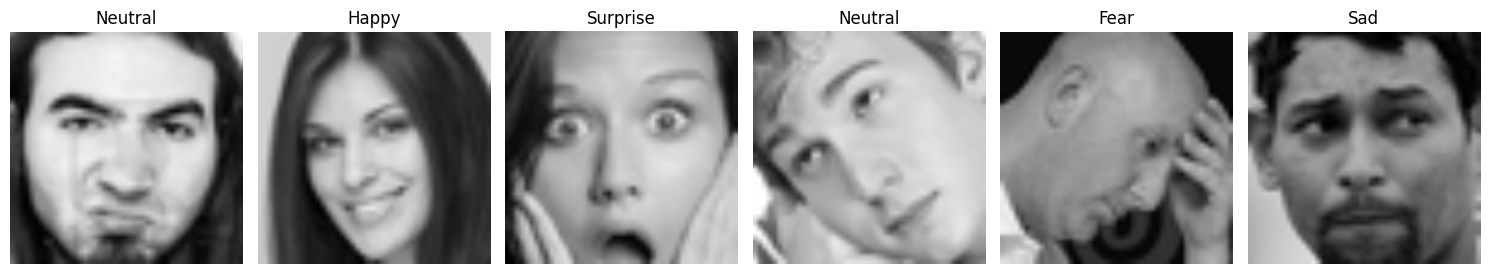

In [23]:
# --- Visualize a few FER2013 images with emotion labels ---

# Get one batch from the FER train loader
images, labels = next(iter(fer_train_loader))

# Get emotion class names from the dataset features
emotion_names = fer["train"].features["label"].names

num_show = 6  # how many images to display
fig, axes = plt.subplots(1, num_show, figsize=(15, 3))

for i in range(num_show):
    img = images[i].cpu()
    img = denormalize(img).clamp(0, 1)  # back to [0,1]

    label_idx = labels[i].item()
    emotion_str = emotion_names[label_idx]

    axes[i].imshow(np.transpose(img.numpy(), (1, 2, 0)))
    axes[i].set_title(emotion_str)
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## Step 10.1 – New model with an emotion head

In [24]:
class AgeGenderEmotionNet(nn.Module):
    """
    MobileNetV2 backbone with three heads:

    (added one extra linear layer: emotion_head)

      - age:    3 classes (child, adult, elderly)
      - gender: 2 classes (male, female)
      - emotion: 7 classes (FER2013 emotions)
    """
    def __init__(self):
        super().__init__()

        # 1) Load pretrained MobileNetV2 (ImageNet weights)
        self.backbone = models.mobilenet_v2(pretrained=True)

        # 2) Get feature size (usually 1280)
        in_features = self.backbone.classifier[1].in_features

        # 3) Remove the original classifier (ImageNet 1000 classes)
        self.backbone.classifier = nn.Identity()

        # 4) Age and gender heads (same as before)
        self.age_head = nn.Linear(in_features, 3)    # child/adult/elderly
        self.gender_head = nn.Linear(in_features, 2) # male/female

        # 5) New emotion head (7 classes from FER2013)
        self.emotion_head = nn.Linear(in_features, 7)

    def forward(self, x):
        feats = self.backbone(x)  # shared features
        age_logits = self.age_head(feats)
        gender_logits = self.gender_head(feats)
        emotion_logits = self.emotion_head(feats)
        return age_logits, gender_logits, emotion_logits


## Step 10.2 – Create this new model and load age+gender weights

In [25]:
# --- Create the new 3-head model ---

model = AgeGenderEmotionNet().to(device)

# --- Load saved weights for backbone + age/gender heads ---

checkpoint = torch.load("age_gender_mobilenetv2.pth", map_location=device)

missing, unexpected = model.load_state_dict(checkpoint["model_state_dict"], strict=False)

print("Missing keys (should be only emotion_head):", missing)
print("Unexpected keys:", unexpected)


Missing keys (should be only emotion_head): ['emotion_head.weight', 'emotion_head.bias']
Unexpected keys: []


## 10.3 Freeze everything except the emotion head

In [26]:
# --- Freeze all parameters first ---

for param in model.parameters():
    param.requires_grad = False

# --- Unfreeze only the emotion head ---

for param in model.emotion_head.parameters():
    param.requires_grad = True

# Check how many parameters are trainable
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Total parameters:     2,239,244
Trainable parameters: 8,967


## 10.4 Define emotion loss + optimizer

In [27]:
# --- Loss just for emotion classification ---

emotion_criterion = nn.CrossEntropyLoss()

# --- Optimizer: only train parameters with requires_grad=True (emotion head) ---

emotion_optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-4
)

print("Emotion optimizer configured.")


Emotion optimizer configured.


## 10.5 Run a tiny emotion-only training loop

In [28]:
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


In [29]:
# Create a Timer instance to measure the total runtime of the emotion training
timer = Timer()

# Start measuring the wall-clock time for the complete emotion training process
timer.start()  # ⏱ begins emotion training timing

# Maximum number of epochs for emotion training.
# Training may stop earlier if early stopping is triggered.
NUM_EPOCHS_EMOTION = 20

# Initialize early stopping for emotion classification.
# patience=3  → stop training if validation loss does not improve for 3 epochs
# min_delta=0 → any reduction in validation loss is considered an improvement
early_stopper_emotion = EarlyStopping(patience=3, min_delta=0.0)

# =========================
# EMOTION TRAINING LOOP
# =========================
for epoch in range(1, NUM_EPOCHS_EMOTION + 1):
    # Print epoch progress information
    print(f"\nEmotion Epoch {epoch}/{NUM_EPOCHS_EMOTION}")
    print("-" * 40)

    # -------------------------------------------------
    # TRAINING PHASE
    # -------------------------------------------------
    # Set model to training mode.
    # Only the emotion head has trainable parameters;
    # other heads (age and gender) are frozen.
    model.train()

    # Initialize accumulators for training statistics
    train_loss_sum = 0.0     # Cumulative training loss
    train_acc_sum = 0.0      # Cumulative training accuracy
    train_batches = 0        # Number of processed batches

    # Iterate over all emotion training batches
    for images, labels in fer_train_loader:
        # Move images and emotion labels to the selected device (CPU/GPU)
        images = images.to(device)
        labels = labels.to(device)

        # Reset gradients from the previous optimization step
        emotion_optimizer.zero_grad()

        # Forward pass through the shared backbone and all heads
        # The model returns three outputs:
        #  - age_logits
        #  - gender_logits
        #  - emotion_logits
        # Only emotion_logits are used here
        _, _, emotion_logits = model(images)

        # Compute emotion classification loss
        loss = emotion_criterion(emotion_logits, labels)

        # Backpropagation:
        # Compute gradients for emotion head parameters
        loss.backward()

        # Update only emotion head weights
        emotion_optimizer.step()

        # Accumulate loss and accuracy for this batch
        train_loss_sum += loss.item()
        train_acc_sum += accuracy_from_logits(emotion_logits, labels)
        train_batches += 1

    # Compute average training loss and accuracy across all batches
    avg_train_loss = train_loss_sum / train_batches
    avg_train_acc = train_acc_sum / train_batches

    # Print training metrics for the current epoch
    print(f"Train emotion loss: {avg_train_loss:.4f}")
    print(f"Train emotion acc:  {avg_train_acc:.4f}")

    # -------------------------------------------------
    # VALIDATION PHASE
    # -------------------------------------------------
    # Switch model to evaluation mode.
    # This disables Dropout and BatchNorm updates.
    model.eval()

    # Initialize accumulators for validation statistics
    val_loss_sum = 0.0
    val_acc_sum = 0.0
    val_batches = 0

    # Disable gradient computation during validation
    # This reduces memory usage and improves inference speed
    with torch.no_grad():
        # Iterate over all validation batches
        for images, labels in fer_val_loader:
            # Move validation data to the correct device
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass through the model (inference only)
            _, _, emotion_logits = model(images)

            # Compute validation loss
            loss = emotion_criterion(emotion_logits, labels)

            # Accumulate validation loss and accuracy
            val_loss_sum += loss.item()
            val_acc_sum += accuracy_from_logits(emotion_logits, labels)
            val_batches += 1

    # Compute average validation loss and accuracy
    avg_val_loss = val_loss_sum / val_batches
    avg_val_acc = val_acc_sum / val_batches

    # Print validation metrics for the current epoch
    print(f"Val emotion loss: {avg_val_loss:.4f}")
    print(f"Val emotion acc:  {avg_val_acc:.4f}")

    # -------------------------------------------------
    # EARLY STOPPING CHECK
    # -------------------------------------------------
    # Monitor validation loss to detect overfitting.
    # Training stops if no improvement is observed
    # for 'patience' consecutive epochs.
    if early_stopper_emotion.step(avg_val_loss):
        print("Early stopping (emotion) triggered.")
        break

# Stop the timer and report the total emotion training runtime
timer.stop("Emotion training")  # ⏱ end timing

# Print summary
#timer.summary()



Emotion Epoch 1/20
----------------------------------------
Train emotion loss: 1.7163
Train emotion acc:  0.3111
Val emotion loss: 1.6791
Val emotion acc:  0.3390

Emotion Epoch 2/20
----------------------------------------
Train emotion loss: 1.6449
Train emotion acc:  0.3608
Val emotion loss: 1.6305
Val emotion acc:  0.3738

Emotion Epoch 3/20
----------------------------------------
Train emotion loss: 1.6065
Train emotion acc:  0.3827
Val emotion loss: 1.5992
Val emotion acc:  0.3862

Emotion Epoch 4/20
----------------------------------------
Train emotion loss: 1.5801
Train emotion acc:  0.3939
Val emotion loss: 1.5766
Val emotion acc:  0.3936

Emotion Epoch 5/20
----------------------------------------
Train emotion loss: 1.5595
Train emotion acc:  0.4054
Val emotion loss: 1.5689
Val emotion acc:  0.3911

Emotion Epoch 6/20
----------------------------------------
Train emotion loss: 1.5405
Train emotion acc:  0.4164
Val emotion loss: 1.5401
Val emotion acc:  0.4114

Emotion E

## Step 11 – Save the age+gender+emotion model

### Done as a last step after inference part is finished to prepare deployment

In [30]:
# --- Step 11: Save final multi-head model (age + gender + emotion) ---

final_checkpoint_path = "age_gender_emotion_mobilenetv2.pth"

final_checkpoint = {
    "model_state_dict": model.state_dict(),
    "emotion_epochs": NUM_EPOCHS_EMOTION,
}

torch.save(final_checkpoint, final_checkpoint_path)
print(f"Final multi-head model saved to {final_checkpoint_path}")


Final multi-head model saved to age_gender_emotion_mobilenetv2.pth


### For final inference + ONNX export

In [31]:
torch.save(model.state_dict(), "/content/drive/MyDrive/my_final_model.pth")
